In [1]:
import pandas as pd
import zipfile

file_names = ["former_names.csv", "goalscorers.csv", "results.csv", "shootouts.csv"]
dataframes = {}

with zipfile.ZipFile("archive.zip", "r") as files:
    for f_name in file_names:
        with files.open(f_name) as f:
            dataframes[f_name] = pd.read_csv(f)

df_former_names = dataframes['former_names.csv']
df_goalscorers = dataframes["goalscorers.csv"]
df_results = dataframes["results.csv"]
df_shootouts = dataframes["shootouts.csv"]

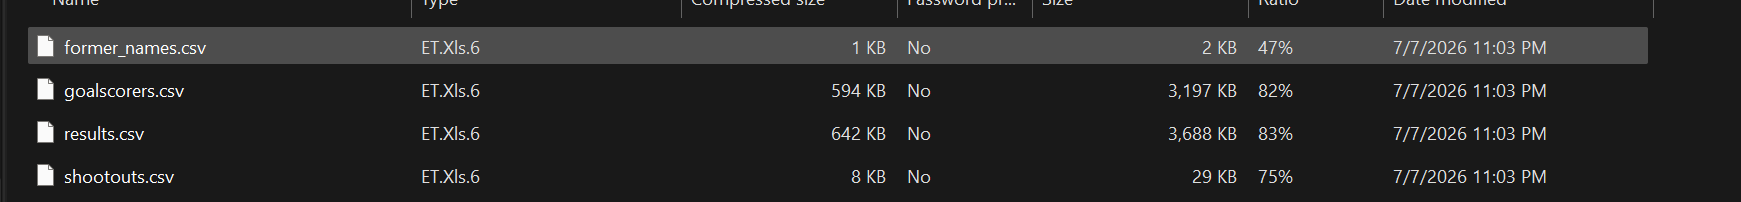

In [2]:
df_former_names['current'].unique()

<StringArray>
[              'Benin',        'Burkina Faso',             'Curaçao',
      'Czechoslovakia',            'DR Congo',            'Djibouti',
               'Egypt',            'Eswatini',               'Ghana',
       'Guinea-Bissau',              'Guyana',           'Indonesia',
              'Israel',              'Malawi',            'Malaysia',
             'Myanmar',     'North Macedonia',    'Northern Ireland',
 'Republic of Ireland',              'Russia',               'Samoa',
              'Serbia',           'Sri Lanka',            'Suriname',
            'Tanzania',             'Vanuatu',              'Zambia',
            'Zimbabwe']
Length: 28, dtype: str

In [3]:
df_goalscorers

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
47881,2026-07-07,Argentina,Egypt,Egypt,Yasser Ibrahim,15.0,False,False
47882,2026-07-07,Argentina,Egypt,Egypt,Mostafa Ziko,67.0,False,False
47883,2026-07-07,Argentina,Egypt,Argentina,Cristian Romero,79.0,False,False
47884,2026-07-07,Argentina,Egypt,Argentina,Lionel Messi,83.0,False,False


In [4]:
df_results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True


In [5]:
df_results.shape

(49505, 9)

In [6]:
df_results.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')

In [7]:
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [10]:
df_results["date"] = pd.to_datetime(df_results["date"])

first_match = df_results["date"].min()
last_match = df_results["date"].max()

print(f"First match - {first_match}")
print(f"Last match - {last_match}")

First match - 1872-11-30 00:00:00
Last match - 2026-07-11 00:00:00


In [13]:
df_results_filtered = df_results[df_results["date"] >= "1990-01-01"].copy()
df_results_filtered

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
17118,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True
17119,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True
17120,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False
17121,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True
17122,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True
...,...,...,...,...,...,...,...,...,...
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True


In [22]:
def get_results(row):
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    else:
        return "draw"

df_results_filtered["results"] = df_results_filtered.apply(get_results, axis=1)
df_results_filtered.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,results
17118,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,home_win
17119,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,home_win
17120,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,home_win
17121,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,home_win
17122,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True,draw


In [18]:
df_results_filtered["results"].value_counts()

results
home_win    15697
away_win     9072
draw         7618
Name: count, dtype: int64

In [23]:
df_results_filtered.isnull().sum()

date          0
home_team     0
away_team     0
home_score    3
away_score    3
tournament    0
city          0
country       0
neutral       0
results       0
dtype: int64

In [20]:
df_results_filtered[df_results_filtered["home_score"].isnull()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,results
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True,draw
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True,draw
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,draw
49504,2026-07-11,Argentina,Switzerland,NaN,NaN,FIFA World Cup,Kansas City,United States,True,draw


In [24]:
df_results_filtered.loc[49501, ["home_score", "away_score"]] = [2, 0]
df_results_filtered.loc[49502, ["home_score", "away_score"]] = [2, 1]


In [27]:
df_goalscorers.tail(5)

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
47881,2026-07-07,Argentina,Egypt,Egypt,Yasser Ibrahim,15.0,False,False
47882,2026-07-07,Argentina,Egypt,Egypt,Mostafa Ziko,67.0,False,False
47883,2026-07-07,Argentina,Egypt,Argentina,Cristian Romero,79.0,False,False
47884,2026-07-07,Argentina,Egypt,Argentina,Lionel Messi,83.0,False,False
47885,2026-07-07,Argentina,Egypt,Argentina,Enzo Fernández,90.0,False,False


In [28]:
new_goals = [
    {
        "date": "2026-07-10",
        "home_team": "France",
        "away_team": "Morocco",
        "team": "France",
        "scorer": "Ousmane Dembélé",
        "minute": 66,
        "own_goal": False,
        "penalty": False
    },
        {
        "date": "2026-07-10",
        "home_team": "France",
        "away_team": "Morocco",
        "team": "France",
        "scorer": "Kylian Mbappé",
        "minute": 60,
        "own_goal": False,
        "penalty": False
    },
        {
        "date": "2026-07-11",
        "home_team": "Spain",
        "away_team": "Belgium",
        "team": "Spain",
        "scorer": "Mikel Merino",
        "minute": 88,
        "own_goal": False,
        "penalty": False
    },
            {
        "date": "2026-07-11",
        "home_team": "Spain",
        "away_team": "Belgium",
        "team": "Spain",
        "scorer": "Fabián Ruiz",
        "minute": 30,
        "own_goal": False,
        "penalty": False
    },
            {
        "date": "2026-07-11",
        "home_team": "Spain",
        "away_team": "Belgium",
        "team": "Belgium",
        "scorer": "Charles De Ketelaere",
        "minute": 41,
        "own_goal": False,
        "penalty": False
    },
]

new_row = pd.DataFrame(new_goals)

df_goalscorers = pd.concat([df_goalscorers, new_row], ignore_index=True)
df_goalscorers

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
47886,2026-07-10,France,Morocco,France,Ousmane Dembélé,66.0,False,False
47887,2026-07-10,France,Morocco,France,Kylian Mbappé,60.0,False,False
47888,2026-07-11,Spain,Belgium,Spain,Mikel Merino,88.0,False,False
47889,2026-07-11,Spain,Belgium,Spain,Fabián Ruiz,30.0,False,False


In [30]:
df_goalscorers.sort_values("date").reset_index(drop=True)
df_results_filtered.sort_values("date").reset_index(drop=True)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,results
0,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,home_win
1,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,home_win
2,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,home_win
3,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,home_win
4,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True,draw
...,...,...,...,...,...,...,...,...,...,...
32382,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True,draw
32383,2026-07-09,France,Morocco,2.0,0.0,FIFA World Cup,Foxborough,United States,True,home_win
32384,2026-07-10,Spain,Belgium,2.0,1.0,FIFA World Cup,Inglewood,United States,True,draw
32385,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,draw


In [32]:
df_results_filtered.shape

(32387, 10)

In [33]:
df_results_filtered.tail(20)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,results
49485,2026-07-01,Belgium,Senegal,3.0,2.0,FIFA World Cup,Seattle,United States,True,home_win
49486,2026-07-01,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,Santa Clara,United States,False,home_win
49487,2026-07-02,Spain,Austria,3.0,0.0,FIFA World Cup,Inglewood,United States,True,home_win
49488,2026-07-02,Portugal,Croatia,2.0,1.0,FIFA World Cup,Toronto,Canada,True,home_win
49489,2026-07-02,Switzerland,Algeria,2.0,0.0,FIFA World Cup,Vancouver,Canada,True,home_win
49490,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,Arlington,United States,True,draw
49491,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,Miami Gardens,United States,True,home_win
49492,2026-07-03,Colombia,Ghana,1.0,0.0,FIFA World Cup,Kansas City,United States,True,home_win
49493,2026-07-04,Canada,Morocco,0.0,3.0,FIFA World Cup,Houston,United States,True,away_win
49494,2026-07-04,Paraguay,France,0.0,1.0,FIFA World Cup,Philadelphia,United States,True,away_win


In [36]:
df_results[df_results["date"] <= "2026-01-01"]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49089,2025-12-30,Botswana,DR Congo,0.0,3.0,African Cup of Nations,Rabat,Morocco,True
49090,2025-12-31,Equatorial Guinea,Algeria,1.0,3.0,African Cup of Nations,Rabat,Morocco,True
49091,2025-12-31,Sudan,Burkina Faso,0.0,2.0,African Cup of Nations,Casablanca,Morocco,True
49092,2025-12-31,Gabon,Ivory Coast,2.0,3.0,African Cup of Nations,Marrakesh,Morocco,True


In [42]:
INITIAL_ELO = 1500

elo_ratings = {}

def get_elo(team):
    return elo_ratings.get(team, INITIAL_ELO)

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def get_factor(tournament):
    if 'World Cup' in tournament:
        return 50 
    elif 'UEFA Euro' in tournament or 'Copa América' in tournament or 'African Cup of Nations' in tournament:
        return 40  
    elif 'qualification' in tournament.lower() or 'UEFA Nations League' in tournament:
        return 25
    elif 'Friendly' in tournament:
        return 10 
    else:
        return 20  


def update_elo(home, away, home_score, away_score, tournament):
    home_elo = get_elo(home)
    away_elo = get_elo(away)

    exp_home = expected_score(home_elo, away_elo)
    exp_away = 1 - exp_home

    if home_score > away_score:
        actual_home, actual_away = 1, 0
    elif home_score < away_score:
        actual_home, actual_away = 0, 1
    else:
        actual_home, actual_away = 0.5, 0.5

    margin = abs(home_score - away_score)
    margin_multiplier = 1 if margin <= 1 else (1.5 if margin == 2 else 1.75)

    K_dynamic = get_factor(tournament)

    new_home_elo = home_elo + K_dynamic * margin_multiplier * (actual_home - exp_home)
    new_away_elo = away_elo + K_dynamic * margin_multiplier * (actual_away - exp_away)

    elo_ratings[home] = new_home_elo
    elo_ratings[away] = new_away_elo

    return home_elo, away_elo


pre_match_home_elo = []
pre_match_away_elo = []

for _, row in df_results_filtered.iterrows():
    h_elo, a_elo = update_elo(
        row['home_team'], 
        row['away_team'], 
        row['home_score'], 
        row['away_score'], 
        row['tournament']
    )
    pre_match_home_elo.append(h_elo)
    pre_match_away_elo.append(a_elo)

df_results_filtered['home_elo'] = pre_match_home_elo
df_results_filtered['away_elo'] = pre_match_away_elo
df_results_filtered['elo_diff'] = df_results_filtered['home_elo'] - df_results_filtered['away_elo']

print("Dinamik K-faktor asosidagi Elo ustunlari muvaffaqiyatli qo'shildi. Namuna:")
df_results_filtered[['date', 'home_team', 'away_team', 'tournament', 'home_elo', 'away_elo', 'elo_diff', 'results']].tail(10)

Dinamik K-faktor asosidagi Elo ustunlari muvaffaqiyatli qo'shildi. Namuna:


,date,home_team,away_team,tournament,home_elo,away_elo,elo_diff,results
49495,2026-07-05,Brazil,Norway,FIFA World Cup,2034.866605,1940.094548,94.772057,away_win
49496,2026-07-05,Mexico,England,FIFA World Cup,1997.722609,2068.258067,-70.535458,away_win
49497,2026-07-06,Portugal,Spain,FIFA World Cup,1981.628073,2134.329911,-152.701838,away_win
49498,2026-07-06,United States,Belgium,FIFA World Cup,1931.158260,1934.266351,-3.108091,away_win
49499,2026-07-07,Argentina,Egypt,FIFA World Cup,2131.862913,1837.853288,294.009626,home_win
49500,2026-07-07,Switzerland,Colombia,FIFA World Cup,1939.067870,2010.947402,-71.879532,draw
49501,2026-07-09,France,Morocco,FIFA World Cup,2133.302513,2031.011591,102.290922,home_win
49502,2026-07-10,Spain,Belgium,FIFA World Cup,2148.998931,1977.624983,171.373949,draw
49503,2026-07-11,Norway,England,FIFA World Cup,1971.749696,2088.251232,-116.501536,draw
49504,2026-07-11,Argentina,Switzerland,FIFA World Cup,2139.635573,1944.167468,195.468106,draw


In [43]:
df_results_filtered

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,results,home_elo,away_elo,elo_diff
17118,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,home_win,1500.000000,1500.000000,0.000000
17119,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,home_win,1508.750000,1500.000000,8.750000
17120,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,home_win,1500.000000,1500.000000,0.000000
17121,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,home_win,1500.000000,1500.000000,0.000000
17122,1990-01-20,Malawi,Tanzania,2.0,2.0,Friendly,Lobamba,Swaziland,True,draw,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49500,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,Vancouver,Canada,True,draw,1939.067870,2010.947402,-71.879532
49501,2026-07-09,France,Morocco,2.0,0.0,FIFA World Cup,Foxborough,United States,True,home_win,2133.302513,2031.011591,102.290922
49502,2026-07-10,Spain,Belgium,2.0,1.0,FIFA World Cup,Inglewood,United States,True,draw,2148.998931,1977.624983,171.373949
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,draw,1971.749696,2088.251232,-116.501536


In [47]:
model_df = df_results_filtered[['date', 'home_team', 'away_team', 'elo_diff', 'neutral', 'results']].copy()

model_df['is_world_cup'] = df_results_filtered['tournament'].str.contains('World Cup', case=False, na=False)

print(model_df.shape)
model_df.sample(10)

(32387, 7)


,date,home_team,away_team,elo_diff,neutral,results,is_world_cup
28668,2004-10-09,Scotland,Norway,-26.989223,False,away_win,True
38001,2014-09-04,Iraq,Peru,29.899853,True,away_win,False
23387,1999-03-10,Guadeloupe,Dominica,-0.596281,False,home_win,False
21455,1996-10-25,Bahrain,Qatar,-109.584964,True,away_win,False
34820,2011-06-09,Cuba,Mexico,-281.365614,True,away_win,False
49249,2026-03-31,Wales,Northern Ireland,154.213335,False,draw,False
23588,1999-06-06,Guatemala,Iran,-200.262595,True,draw,False
34433,2010-12-18,Iraq,Syria,-7.657781,False,away_win,False
22345,1997-10-01,Tanzania,Kenya,-142.398414,False,away_win,False
41316,2018-03-21,Antigua and Barbuda,Bermuda,-108.834086,False,home_win,False


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, classification_report

model_df = model_df.sort_values('date').reset_index(drop=True)

train = model_df[model_df['date'] < '2026-01-01']
test = model_df[model_df['date'] >= '2026-01-01']

print("Training matches:", len(train))
print("Test matches (2026):", len(test))

feature_cols = ['elo_diff', 'neutral', 'is_world_cup']
X_train, y_train = train[feature_cols], train['results']
X_test, y_test = test[feature_cols], test['results']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)

print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nClassification report:")
print(classification_report(y_test, preds))

Training matches: 31976
Test matches (2026): 411

Accuracy: 0.5693430656934306

Classification report:
              precision    recall  f1-score   support

    away_win       0.52      0.54      0.53       107
        draw       0.00      0.00      0.00       104
    home_win       0.59      0.88      0.70       200

    accuracy                           0.57       411
   macro avg       0.37      0.47      0.41       411
weighted avg       0.42      0.57      0.48       411



C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [52]:
from sklearn.metrics import log_loss

print("Model's class order:", model.classes_)

ll = log_loss(y_test, probs, labels=model.classes_)
print("Log-loss:", ll)

import numpy as np
baseline_probs = np.tile(y_train.value_counts(normalize=True)[model.classes_].values, (len(y_test), 1))
baseline_ll = log_loss(y_test, baseline_probs, labels=model.classes_)
print("Baseline log-loss (no model, just historical averages):", baseline_ll)



Model's class order: ['away_win' 'draw' 'home_win']
Log-loss: 0.9134105067879832
Baseline log-loss (no model, just historical averages): 1.05000185285498


In [78]:
def predict_matchup(team_a, team_b, neutral=True, is_world_cup=True):
    """Returns win/draw/loss probabilities for team_a vs team_b using current Elo ratings."""
    elo_diff = get_elo(team_a) - get_elo(team_b)
    X = pd.DataFrame([[elo_diff, neutral, is_world_cup]], columns=feature_cols)
    probs = model.predict_proba(X)[0]
    return dict(zip(model.classes_, probs))

print(predict_matchup('Portugal', 'Spain'))

{'away_win': np.float64(0.5882286593788015), 'draw': np.float64(0.22596359063233426), 'home_win': np.float64(0.18580774998886418)}
